# Домашнє завдання: ETL-пайплайни для аналітиків даних

Це ДЗ передбачене під виконання на локальній машині. Виконання з Google Colab буде суттєво ускладнене.

## Підготовка
1. Переконайтесь, що у вас встановлені необхідні бібліотеки:
   ```bash
   pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv
   ```

2. Створіть файл `.env` з параметрами підключення до бази даних classicmodels. Базу даних ви можете отримати через

  - docker-контейнер згідно існтрукції в [документі](https://www.notion.so/hannapylieva/Docker-1eb94835849480c9b2e7f5dc22ee4df9), також відео інструкції присутні на платформі - уроки "MySQL бази, клієнт для роботи з БД, Docker і ChatGPT для запитів" та "Як встановити Docker для роботи з базами даних без терміналу"
  - або встановивши локально цю БД - для цього перегляньте урок "Опціонально. Встановлення MySQL та  БД Сlassicmodels локально".
  
  Приклад `.env` файлу ми створювали в лекції. Ось його обовʼязкове наповнення:
    ```
    DB_HOST=your_host
    DB_PORT=3306 або 3307 - той, який Ви налаштували
    DB_USER=your_username
    DB_PASSWORD=your_password
    DB_NAME=classicmodels
    ```
  Якщо ви створили цей файл під час перегляду лекції - **новий створювати не треба**. Замініть лише назву БД, або пропишіть назву в коді створення підключення (замість отримання назви цільової БД зі змінних оточення). Але переконайтесь, що до `.env` файл лежить в тій самій папці, що і цей ноутбук.

  **УВАГА!** НЕ копіюйте скрит для **створення** `.env` файлу. В лекції він наводиться для прикладу. І давалось пояснення, що в реальних проєктах ми НІКОЛИ не пишемо доступи до бази в коді. Копіювання скрипта для створення `.env` файлу сюди в ДЗ буде вважатись грубою помилкою і ми зніматимемо бали.

3. Налаштуйте підключення через SQLAlchemy до БД за прикладом в лекції.

Рекомендую вивести (відобразити) змінну engine після створення. Вона має бути не None! Якщо None - значить у Вас не підтягнулись налаштування з .env файла.

Ви також можете налаштувати параметри підключення до БД без .env файла, просто прописавши текстом в відповідних місцях. Це - не рекомендований підхід.

In [1]:
import datetime
import os
import sqlalchemy as sa
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import logging
import requests

In [2]:
def create_connection():
    """
    Створює підключення через SQLAlchemy
    """
    # Завантажуємо змінні середовища
    load_dotenv()

    # Отримуємо параметри з environment variables
    host = os.getenv('DB_HOST', '127.0.0.1')
    port = os.getenv('DB_PORT', '3306')
    user = os.getenv('DB_USER')
    password = os.getenv('DB_PASSWORD')
    database = os.getenv('DB_NAME')

    if not all([user, password, database]):
        raise ValueError("Не всі параметри БД задані в .env файлі!")

    # Створюємо connection string
    connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"

    # Створюємо engine з connection pooling
    engine = create_engine(
        connection_string,
        pool_size=2,            # Розмір пулу підключень
        max_overflow=20,        # Максимальна кількість додаткових підключень
        pool_pre_ping=True,     # Перевірка підключення перед використанням
        echo=False              # Логування SQL запитів (True для debug)
    )

    # Тестуємо підключення
    try:
        with engine.connect() as conn:
            result = conn.execute(text("SELECT 1"))
            result.fetchone()

        print("✅ Підключення до БД успішне!")
        print(f"🔗 host={host}, port={port}, db={database}")
        
        return engine

    except Exception as e:
        print(f"❌ Помилка підключення: {e}")
        return None

# Створюємо підключення
engine = create_connection()

✅ Підключення до БД успішне!
🔗 host=127.0.0.1, port=3306, db=classicmodels


### Завдання 1: Створення таблиці курсів валют та API інтеграція (2 бали)

**Повторіть процедуру з лекції:** створіть таблицю для курсів валют, але вже в цій базі даних. Результатом має бути нова таблиця з курсами валют USD, EUR, UAH в БД (можна завантажити більше валют). Продемонструйте, що таблиця була додана, використовуючи SELECT.

Тобто тут ви можете прямо скопіювати код з лекції, внести необхідні зміни і запустити. Головне - отримати таблицю в БД classicmodels.

In [3]:
# Створюємо таблицю для курсів валют (сучасний спосіб)
def create_currency_table(engine):
    """Створює таблицю через SQLAlchemy"""

    create_table_sql = text("""
    CREATE TABLE IF NOT EXISTS currency_rates (
        id INT AUTO_INCREMENT PRIMARY KEY,
        currency_code VARCHAR(3) NOT NULL,
        rate_to_usd DECIMAL(10, 6) NOT NULL,
        rate_date DATE NOT NULL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
        INDEX idx_currency_date (currency_code, rate_date),
        UNIQUE KEY unique_currency_date (currency_code, rate_date)
    )
    """)

    with engine.connect() as conn:
        # тут лише одна транзакція - conn.begin() не треба
        conn.execute(create_table_sql)

    print("✅ Таблиця currency_rates створена")

def fetch_exchange_rates():
    """Отримує курси валют з API"""
    try:
        # Безкоштовний API курсів валют
        url = "https://api.exchangerate-api.com/v4/latest/USD"
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        data = response.json()

        # Валюти, що нас цікавлять
        currencies = ['USD', 'EUR', 'UAH']
        rates = {}

        for currency in currencies:
            if currency in data['rates']:
                # Зберігаємо курс до USD (скільки одиниць валюти за 1 USD)
                rates[currency] = data['rates'][currency]

        return rates, datetime.date.today()

    except Exception as e:
        print(f"❌ Помилка API: {e}")
        return None, None

def save_exchange_rates(engine, rates_dict, rate_date):
    """Зберігає курси в БД з обробкою конфліктів"""

    if not rates_dict:
        print("❌ Немає даних для збереження")
        return False

    # SQL з ON DUPLICATE KEY UPDATE для MySQL
    insert_sql = text("""
    INSERT INTO currency_rates (currency_code, rate_to_usd, rate_date)
    VALUES (:currency, :rate, :date)
    ON DUPLICATE KEY UPDATE
        rate_to_usd = VALUES(rate_to_usd),
        updated_at = CURRENT_TIMESTAMP
    """)

    try:
        with engine.connect() as conn:
            with conn.begin():  # Транзакція для всіх вставок
                for currency, rate in rates_dict.items():
                    conn.execute(insert_sql, {
                        'currency': currency,
                        'rate': rate,
                        'date': rate_date
                    })

        print(f"✅ Збережено {len(rates_dict)} курсів валют на {rate_date}")
        return True

    except Exception as e:
        print(f"❌ Помилка збереження: {e}")
        return False

In [4]:
# Виконуємо повний цикл API → БД
create_currency_table(engine)

print("📡 Отримуємо курси валют...")
rates, date = fetch_exchange_rates()

if rates:
    print(f"Отримані курси на {date}:")
    for currency, rate in rates.items():
        print(f"  1 USD = {rate:.4f} {currency}")

    # Зберігаємо в БД
    if save_exchange_rates(engine, rates, date):
        # Перевіряємо збережені дані
        verification_df = pd.read_sql(
            "SELECT * FROM currency_rates ORDER BY created_at DESC LIMIT 10",
            engine
        )
        print("\nЗбережені дані:")
        display(verification_df)

✅ Таблиця currency_rates створена
📡 Отримуємо курси валют...
Отримані курси на 2026-03-15:
  1 USD = 1.0000 USD
  1 USD = 0.8730 EUR
  1 USD = 44.1700 UAH
✅ Збережено 3 курсів валют на 2026-03-15

Збережені дані:


,id,currency_code,rate_to_usd,rate_date,created_at,updated_at
0,1,USD,1.000,2026-03-15,2026-03-15 12:46:43,2026-03-15 15:36:12
1,2,EUR,0.873,2026-03-15,2026-03-15 12:46:43,2026-03-15 15:36:12
2,3,UAH,44.170,2026-03-15,2026-03-15 12:46:43,2026-03-15 15:36:12


# Завдання 2: Створення простого ETL пайплайну (7 балів)

В цьому завданні ми створимо повноцінний ETL процес для аналізу продажів ClassicModels.

Завдання обʼємне і оцінюється відповідно. Ви можете пропустити обчислення якихось з метрик, якщо відчуєте, що вже немає сил робити це завдання. Бал буде виставлено виходячи з виконаного обʼєму та його правильності.

## Що саме треба зробити:

### Extract (Витягування даних):
На цьому етапі треба витягнути дані з БД в pandas.DataFrame для подальшої обробки.
Які дані нам потрібні (кожен пункт - в окремий фрейм даних):
1. **дані про виконані замовлення за 2004 рік** - з'єднати таблиці orders, orderdetails, products, customers
2. **дані про продукти** - назви, категорії, ціни
3. **дані про курси валют** - використати дані з попереднього завдання

### Transform (Обробка даних):

#### 2.1 Додати розрахункові колонки до основної таблиці:
Додайте до DataFrame з продажами такі нові колонки:

- **`profit_per_item`** - прибуток з одного товару (використайте колонки: `priceEach` - `buyPrice`)
- **`total_profit`** - загальний прибуток з товарної позиції (використайте колонки: `profit_per_item` × `quantityOrdered`)
- **`total_amount_eur`** - сума в євро (використайте колонки: `total_amount` / `eur_rate`)

#### 2.2 Створити аналітичну таблицю по країнах (ТОП-5):
Згрупуйте дані по колонці **`country`** та обчисліть для кожної країни:

**Метрики для розрахунку:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Загальний дохід** - сума колонки `total_amount`
- **Загальний прибуток** - сума колонки `total_profit`
- **Кількість проданих товарів** - сума колонки `quantityOrdered`
- **Маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100

**Результат:** Таблиця з 5 найприбутковіших країн, відсортована за загальним доходом (від більшого до меншого).

#### 2.3 Створити аналітичну таблицю по продуктових лініях:
Згрупуйте дані по колонці **`productLine`** та обчисліть ті ж метрики:

**Метрики для розрахунку:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Загальний дохід** - сума колонки `total_amount`
- **Загальний прибуток** - сума колонки `total_profit`
- **Кількість проданих товарів** - сума колонки `quantityOrdered`
- **Маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100

**Результат:** Таблиця з усіма продуктовими лініями, відсортована за загальним доходом.

#### 2.4 Створити підсумкову інформацію (Executive Summary):
Розрахуйте загальні показники бізнесу за 2004 рік:

**Фінансові показники:**
- **Загальний дохід в доларах** - сума всієї колонки `total_amount`
- **Загальний дохід в євро** - сума всієї колонки `total_amount_eur`
- **Загальний прибуток в доларах** - сума всієї колонки `total_profit`
- **Загальна маржа прибутку (%)** - (`загальний прибуток` / `загальний дохід`) × 100
- **Середній розмір замовлення** - середнє значення колонки `total_amount`

**Операційні показники:**
- **Кількість унікальних замовлень** - унікальні значення колонки `orderNumber`
- **Кількість унікальних клієнтів** - унікальні значення колонки `customerName`
- **Період даних** - мінімальна та максимальна дата з колонки `orderDate`

**Топ показники:**
- **Найприбутковіша країна** - перший рядок з таблиці країн (колонка `country`)
- **Найприбутковіша продуктова лінія** - перший рядок з таблиці продуктів (колонка `productLine`)

### Load (Збереження результатів):
В цій частині ми зберігаємо результати наших обчислень.
Використайте приклади коду з лекцій та адаптуйте його під цей ETL процес.
Що Вам потрібно створити:

#### 3.1 Excel файл з трьома вкладками:
- **"Summary"** - підсумкова інформація у вигляді таблиці "Показник - Значення"
- **"Top_Countries"** - аналітика по топ-5 країнах
- **"Product_Lines"** - аналітика по всіх продуктових лініях

#### 3.2 Візуалізація:
- Створіть стовпчикову діаграму топ-5 країн за доходом.
- Створіть pie chart з відсотковим розподілом доходу в USD по продуктових лінійках.

## РЕКОМЕНДАЦІЇ ДО ВИКОНАННЯ:

### Покрокова стратегія виконання:
1. Спочатку протестуйте Extract просто в Jupyter notebook (без функції) - переконайтеся що SQL запит працює і повертає дані за 2004 рік
2. Потім протестуйте кожен Transform окремо - виведіть проміжні результати
3. Нарешті протестуйте Load - перевірте що файли створюються правильно  
4. Тільки після цього обгортайте все в функцію

### Як перевірити що все працює:
- Виводьте на екран, який етап зараз відбувається
- Виведіть кількість записів після кожного кроку
- Покажіть перші 5 рядків кожної аналітичної таблиці
- Перевірте що дати належать 2004 року
- Переконайтеся що маржа прибутку в розумних межах (0-50%)

In [5]:
# EXTRACT: Витягуємо дані з кількох джерел

print("📥 1. EXTRACT - Витягуємо дані про замовлення...")

orders_query = text("""
        SELECT
            o.orderNumber,
            o.orderDate,
            o.requiredDate,
            o.shippedDate,
            o.status,
            c.customerNumber,
            c.customerName,
            c.country,
            od.productCode,
            p.productName,
            p.productLine,
            p.buyPrice,
            od.quantityOrdered,
            od.priceEach,
            (od.quantityOrdered * od.priceEach) AS total_amount
        FROM orders o
        JOIN orderdetails od ON o.orderNumber = od.orderNumber
        JOIN products p ON od.productCode = p.productCode
        JOIN customers c ON o.customerNumber = c.customerNumber
        WHERE YEAR(o.orderDate) = 2004 AND o.status = 'Shipped'
""")

df_orders = pd.read_sql(orders_query, engine)

print(f"✅ Рядків у df_orders: {len(df_orders)}")
display(df_orders.head())

📥 1. EXTRACT - Витягуємо дані про замовлення...
✅ Рядків у df_orders: 1353


,orderNumber,orderDate,requiredDate,shippedDate,status,customerNumber,customerName,country,productCode,productName,productLine,buyPrice,quantityOrdered,priceEach,total_amount
0,10211,2004-01-15,2004-01-25,2004-01-18,Shipped,406,Auto Canal+ Petit,France,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,41,90.92,3727.72
1,10223,2004-02-20,2004-02-29,2004-02-24,Shipped,114,"Australian Collectors, Co.",Australia,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,37,80.39,2974.43
2,10237,2004-04-05,2004-04-12,2004-04-10,Shipped,181,Vitachrome Inc.,USA,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,23,91.87,2113.01
3,10251,2004-05-18,2004-05-24,2004-05-24,Shipped,328,Tekni Collectables Inc.,USA,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,59,93.79,5533.61
4,10263,2004-06-28,2004-07-04,2004-07-02,Shipped,175,Gift Depot Inc.,USA,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,34,89.00,3026.00


In [6]:
print("📥 2. EXTRACT - Витягуємо дані про продукти...")

products_query = text("""
    SELECT
        productCode,
        productName,
        productLine,
        buyPrice,
        MSRP
    FROM products
""")

df_products = pd.read_sql(products_query, engine)

print(f"✅ Рядків у df_products: {len(df_products)}")
display(df_products.head())

📥 2. EXTRACT - Витягуємо дані про продукти...
✅ Рядків у df_products: 110


,productCode,productName,productLine,buyPrice,MSRP
0,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,95.70
1,S10_1949,1952 Alpine Renault 1300,Classic Cars,98.58,214.30
2,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,68.99,118.94
3,S10_4698,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,91.02,193.66
4,S10_4757,1972 Alfa Romeo GTA,Classic Cars,85.68,136.00


In [7]:
print("📥 3. EXTRACT - Витягуємо курси валют...")

rates_query = text("""
    SELECT
        currency_code,
        rate_to_usd,
        rate_date
    FROM currency_rates
    ORDER BY rate_date DESC, currency_code
""")

df_rates = pd.read_sql(rates_query, engine)

print(f"✅ Рядків у df_rates: {len(df_rates)}")
display(df_rates.head())

📥 3. EXTRACT - Витягуємо курси валют...
✅ Рядків у df_rates: 3


,currency_code,rate_to_usd,rate_date
0,EUR,0.873,2026-03-15
1,UAH,44.170,2026-03-15
2,USD,1.000,2026-03-15


In [8]:
# TRANSFORM: Обробляємо та збагачуємо дані в Pandas
print("🔧 2. TRANSFORM - Обробка та збагачення...")

# 1. Беремо курс EUR з таблиці курсів
eur_rate = df_rates.loc[df_rates['currency_code'] == 'EUR', 'rate_to_usd'].iloc[0]
print(f"Курс EUR: {eur_rate}")

# 2. Додаємо розрахункові колонки
df_orders['profit_per_item'] = df_orders['priceEach'] - df_orders['buyPrice']
df_orders['total_profit'] = df_orders['profit_per_item'] * df_orders['quantityOrdered']
df_orders['total_amount_eur'] =  df_orders['total_amount'] * eur_rate

print(f"✅ Рядків після transform: {len(df_orders)}")
display(df_orders.head())

🔧 2. TRANSFORM - Обробка та збагачення...
Курс EUR: 0.873
✅ Рядків після transform: 1353


,orderNumber,orderDate,requiredDate,shippedDate,status,customerNumber,customerName,country,productCode,productName,productLine,buyPrice,quantityOrdered,priceEach,total_amount,profit_per_item,total_profit,total_amount_eur
0,10211,2004-01-15,2004-01-25,2004-01-18,Shipped,406,Auto Canal+ Petit,France,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,41,90.92,3727.72,42.11,1726.51,3254.29956
1,10223,2004-02-20,2004-02-29,2004-02-24,Shipped,114,"Australian Collectors, Co.",Australia,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,37,80.39,2974.43,31.58,1168.46,2596.67739
2,10237,2004-04-05,2004-04-12,2004-04-10,Shipped,181,Vitachrome Inc.,USA,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,23,91.87,2113.01,43.06,990.38,1844.65773
3,10251,2004-05-18,2004-05-24,2004-05-24,Shipped,328,Tekni Collectables Inc.,USA,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,59,93.79,5533.61,44.98,2653.82,4830.84153
4,10263,2004-06-28,2004-07-04,2004-07-02,Shipped,175,Gift Depot Inc.,USA,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,48.81,34,89.00,3026.00,40.19,1366.46,2641.69800


In [9]:
# 2.2 Аналітична таблиця по країнах (ТОП-5)

top_countries = (
    df_orders.groupby('country').agg(
        unique_orders=('orderNumber', 'nunique'),
        total_revenue=('total_amount', 'sum'),
        total_profit=('total_profit', 'sum'),
        total_items_sold=('quantityOrdered', 'sum')
    ).reset_index()
)

top_countries['profit_margin_pct'] = (top_countries['total_profit'] / top_countries['total_revenue'] * 100).round(2)

top_countries = top_countries.sort_values(by='total_revenue', ascending=False).head(5)

print(f"✅ Рядків у top_countries: {len(top_countries)}")
display(top_countries)

✅ Рядків у top_countries: 5


,country,unique_orders,total_revenue,total_profit,total_items_sold,profit_margin_pct
20,USA,52,1485054.44,597654.15,16265,40.24
6,France,19,506660.01,211528.15,5632,41.75
16,Spain,13,392816.48,156131.39,4357,39.75
0,Australia,6,204213.18,78176.66,2232,38.28
11,New Zealand,5,195592.89,78147.87,2229,39.95


In [10]:
# 2.3 Аналітична таблиця по продуктових лініях

productLine_grouped = (
    df_orders.groupby('productLine').agg(
        unique_orders=('orderNumber', 'nunique'),
        total_revenue=('total_amount', 'sum'),       # Загальний дохід
        total_profit=('total_profit', 'sum'),        # Загальний прибуток
        total_items_sold=('quantityOrdered', 'sum')
    ).reset_index()
)

productLine_grouped['profit_margin_pct'] = (productLine_grouped['total_profit'] / productLine_grouped['total_revenue'] * 100).round(2)

productLine_grouped = productLine_grouped.sort_values(by='total_revenue', ascending=False)

print(f"✅ Рядків у productLine_grouped: {len(productLine_grouped)}")
display(productLine_grouped.head())

✅ Рядків у productLine_grouped: 7


,productLine,unique_orders,total_revenue,total_profit,total_items_sold,profit_margin_pct
0,Classic Cars,93,1682980.21,671878.21,15424,39.92
6,Vintage Cars,85,823927.95,337219.36,10487,40.93
1,Motorcycles,37,527243.84,222485.41,5976,42.20
5,Trucks and Buses,39,448702.69,176415.25,4853,39.32
2,Planes,32,438255.50,168722.36,5439,38.50


In [11]:
# 2.4 Підсумкова інформація (Executive Summary) - загальні показники бізнесу за 2004 рік

executive_summary = {}

# Фінансові показники
executive_summary['total_revenue_usd'] = round(df_orders['total_amount'].sum(), 2)
executive_summary['total_revenue_eur'] = round(df_orders['total_amount_eur'].sum(), 2)
executive_summary['total_profit_usd'] = round(df_orders['total_profit'].sum(), 2)
executive_summary['profit_margin_pct'] = round(executive_summary['total_profit_usd'] / executive_summary['total_revenue_usd'] * 100, 2)
executive_summary['avg_order'] = round(df_orders.groupby('orderNumber')['total_amount'].sum().mean(), 2)  # рахуємо суму по кожному замовленню, потім середнє

# Операційні показники
executive_summary['unique_orders'] = df_orders['orderNumber'].nunique()
executive_summary['unique_customers'] = df_orders['customerName'].nunique()
executive_summary['period_start'] = df_orders['orderDate'].min()
executive_summary['period_end'] = df_orders['orderDate'].max()

# Топ показники
executive_summary['top1_country'] = top_countries['country'].iloc[0]
executive_summary['top1_productLine'] = productLine_grouped['productLine'].iloc[0]

print(f"✅ Розраховано Executive Summary")

summary_df = pd.DataFrame(
    executive_summary.items(),
    columns=['Metric', 'Value']
)

display(summary_df)

✅ Розраховано Executive Summary


,Metric,Value
0,total_revenue_usd,4300602.99
1,total_revenue_eur,3754426.41
2,total_profit_usd,1723682.41
3,profit_margin_pct,40.08
4,avg_order,29659.33
5,unique_orders,145
6,unique_customers,87
7,period_start,2004-01-02
8,period_end,2004-12-17
9,top1_country,USA


In [12]:
print("💾 3. LOAD - Збереження результатів...")

# Створюємо директорію для звітів
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# 3.1 Excel звіт для бізнесу
excel_filename = f"{output_dir}/comprehensive_report_{timestamp}.xlsx"

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
    top_countries.to_excel(writer, sheet_name='Top_Countries', index=False)
    productLine_grouped.to_excel(writer, sheet_name='Product_Lines', index=False)

print(f"✅ 📊 Excel файл збережено: {excel_filename}")

💾 3. LOAD - Збереження результатів...
✅ 📊 Excel файл збережено: output/comprehensive_report_20260315_173613.xlsx


📊 Створюємо графік Top-5 країн за доходом...


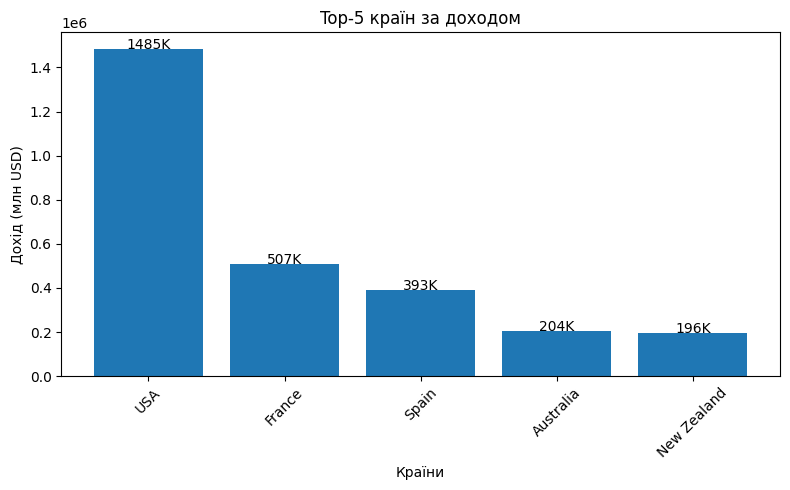

In [13]:
print("📊 Створюємо графік Top-5 країн за доходом...")

plt.figure(figsize=(8,5))
bars = plt.bar(top_countries['country'], top_countries['total_revenue'])

plt.title('Top-5 країн за доходом')
plt.xlabel('Країни')
plt.ylabel('Дохід (млн USD)')
plt.xticks(rotation=45)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f'{value/1000:.0f}K',
        ha='center'
    )

plt.tight_layout();

📊 Створюємо pie chart з розподілом доходу в USD по продуктових лінійках...


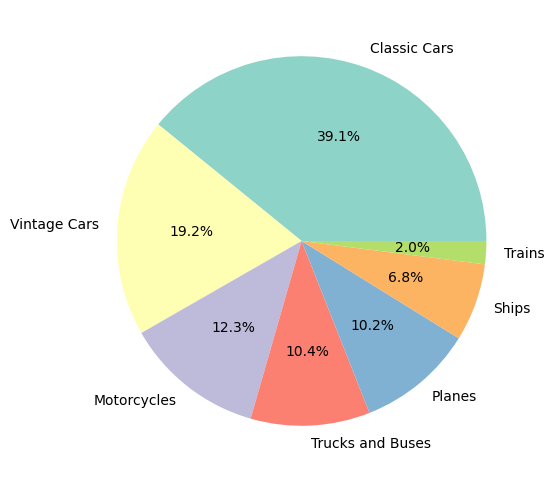

In [14]:
print("📊 Створюємо pie chart з розподілом доходу в USD по продуктових лінійках...")
plt.figure(figsize=(6, 6))
plt.pie(
    productLine_grouped['total_revenue'],
    autopct='%1.1f%%',
    labels=productLine_grouped['productLine'],
    colors=plt.cm.Set3.colors
)
plt.title='Частка доходів по продуктових лінійках',
ylabel='';

**Time spent — 3 годин**

**What I learned:**

- Зрозуміла суть **транзакцій** і їх роль у безпечному збереженні даних у базі.
- Попрактикувала роботу з **API**: отримання даних, обробка JSON та запис результату в БД.
- Краще зрозуміла логіку **ETL-процесу**: **Extract → Transform → Load** та послідовність роботи з ним.
- Закріпила навички написання **SQL-запитів**: вибірка, об’єднання таблиць, фільтрація даних.
- Попрактикувала **обробку даних у pandas**: створення розрахункових колонок, групування, агрегації та підсумкові таблиці.
- Освіжила й закріпила навички **візуалізації даних** у Python для представлення результатів аналізу.
- Навчилась формувати та зберігати **аналітичний Excel-звіт** з кількома вкладками.